In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/omkargurav
/kaggle/input/datasets/omkargurav/face-mask-dataset
/kaggle/input/datasets/omkargurav/face-mask-dataset/data
/kaggle/input/datasets/omkargurav/face-mask-dataset/data/without_mask
/kaggle/input/datasets/omkargurav/face-mask-dataset/data/with_mask


In [4]:
DATASET_PATH = "/kaggle/input/datasets/omkargurav/face-mask-dataset/data"

IMG_SIZE = (160,160)
BATCH_SIZE = 32
SEED = 42

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 7553 files belonging to 2 classes.
Using 6043 files for training.


I0000 00:00:1773152163.062581      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773152163.068797      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 7553 files belonging to 2 classes.
Using 1510 files for validation.
Classes: ['with_mask', 'without_mask']


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

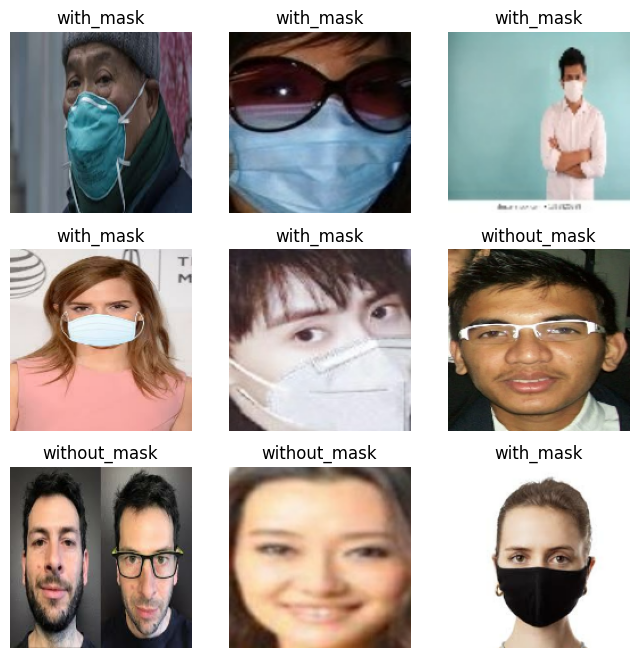

In [7]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [10]:


base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


I0000 00:00:1773148169.058886     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


189/189 ━━━━━━━━━━━━━━━━━━━━ 18s 54ms/step - accuracy: 0.9410 - loss: 0.1324 - val_accuracy: 0.9894 - val_loss: 0.0315
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9797 - loss: 0.0479 - val_accuracy: 0.9914 - val_loss: 0.0249
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.9889 - loss: 0.0359 - val_accuracy: 0.9874 - val_loss: 0.0283
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9914 - loss: 0.0238 - val_accuracy: 0.9887 - val_loss: 0.0272
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9860 - loss: 0.0365 - val_accuracy: 0.9887 - val_loss: 0.0234
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9911 - loss: 0.0240 - val_accuracy: 0.9901 - val_loss: 0.0239
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9913 - loss: 0.0263 - val_accuracy: 0.9861 - val_loss: 0.0344
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.9929 - loss: 0.0197 - val_accuracy: 0.99

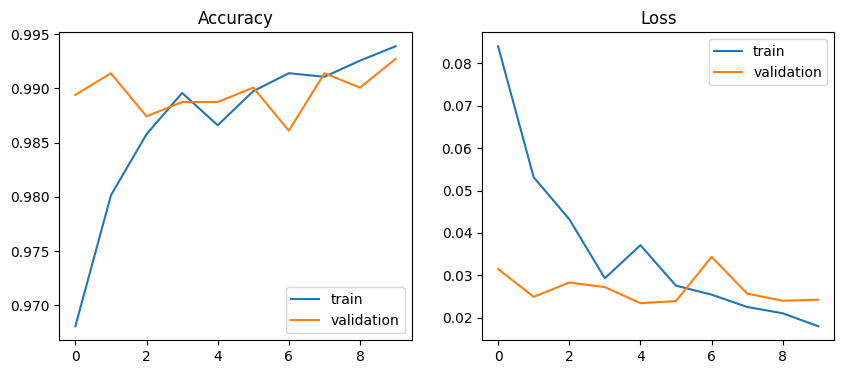

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(acc,label="train")
plt.plot(val_acc,label="validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss,label="train")
plt.plot(val_loss,label="validation")
plt.title("Loss")
plt.legend()

plt.show()

In [18]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9919 - loss: 0.0313
Validation Accuracy: 0.9927152395248413


In [19]:
model.save("/kaggle/working/face_mask_detector.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


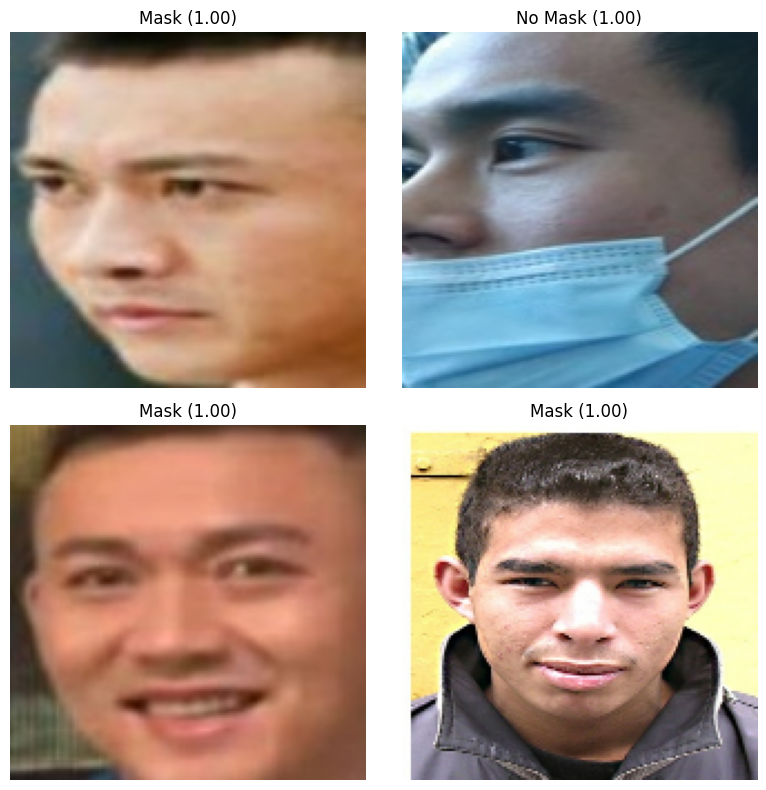

In [21]:
import random

plt.figure(figsize=(8,8))

for images, labels in val_ds.take(1):
    
    for i in range(4):
        
        img = images[i]
        
        pred = model.predict(tf.expand_dims(img,0))[0][0]
        
        label = "Mask" if pred >= 0.5 else "No Mask"
        conf = pred if pred >= 0.5 else 1-pred
        
        plt.subplot(2,2,i+1)
        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"{label} ({conf:.2f})")
        plt.axis("off")

plt.tight_layout()
plt.show()